# Does the Tape Agree With Itself? \U0001F50D
### Four views of the same asset, from the same provider, in one pass

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

Every backtest ever written begins with a download and a leap of faith. This notebook takes the
leap out: ask the same provider for daily, weekly and monthly bars and for the raw prices with
the dividends and splits attached, and then check that the four stories agree.

> \U0001F4D3 **This is the plain-language layer.** The six checks, their severities and the
> planted-fault control are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do the daily bars compound into the weekly ones? | Essentially yes — a few basis points at worst. |
| Can the adjusted close be rebuilt from price, dividends and splits? | Yes, to a fraction of a percent per year. This is the check that matters most. |
| Are any sessions missing? | A handful, and they are visible only because eight tapes were compared against each other. |
| Should you trust a free feed? | More than its reputation suggests — and only after running something like this once. |

## 1 · The claim

> *"You can't do serious research on free data."*

It is the most common objection to every result on this desk, and it is usually asserted rather
than tested. The testable version is narrow and answerable: **does the feed contradict
itself?**

## 2 · So what?

If the adjusted close is wrong, every total-return backtest is wrong by the same amount, in the
same direction, forever — and no amount of statistical care downstream will find it. This is
the one error class that survives every robustness check, because every robustness check reads
the same broken number.

In [2]:
from tape_audit import data, strategy as st

tapes = {tk: data.load_all(tk) for tk in data.TICKERS}
calendar = st.build_calendar({tk: fr["daily_tr"] for tk, fr in tapes.items()})
print(f"as-of {data.AS_OF} | {len(tapes)} tickers x {len(data.FLAVOURS)} flavours")
print(f"reference calendar: {len(calendar):,} sessions "
      f"{calendar[0].date()} -> {calendar[-1].date()}")
for tk, fr in tapes.items():
    print(f"  {tk:6s} daily {len(fr['daily_tr']):5,}  weekly {len(fr['weekly']):5,}  "
          f"monthly {len(fr['monthly']):4,}")

as-of 2026-06-30 | 8 tickers x 4 flavours
reference calendar: 6,901 sessions 1999-01-22 -> 2026-06-30
  SPY    daily 8,411  weekly 1,745  monthly  402
  QQQ    daily 6,869  weekly 1,426  monthly  328
  AAPL   daily 8,430  weekly 1,748  monthly  402
  NVDA   daily 6,901  weekly 1,433  monthly  330
  TSLA   daily 4,025  weekly   836  monthly  193
  VYM    daily 4,933  weekly 1,025  monthly  236
  XLU    daily 6,921  weekly 1,437  monthly  331
  GLD    daily 5,436  weekly 1,129  monthly  260


## 3 · How would we even know?

Six comparisons, each between two things that *must* be equal if the feed is coherent. The
cleverest one is the reconstruction: take the as-traded price, add back every dividend on its
ex-date, multiply through every split, and see whether you land on the provider's own adjusted
series.

## 4 · The teardown

### 4.1 Do the frequencies agree?

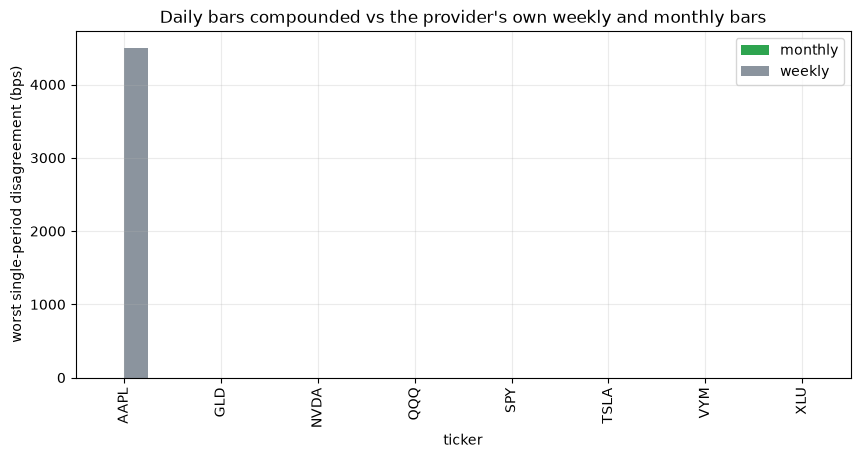

,ticker,frequency,worst diff (bps),median (bps)
0,SPY,weekly,0.0300,0.0000
1,SPY,monthly,0.0200,0.0000
2,QQQ,weekly,0.0200,0.0000
3,QQQ,monthly,0.0100,0.0000
4,AAPL,weekly,"4,503.5800",166.6700
5,AAPL,monthly,0.0100,0.0000
6,NVDA,weekly,0.0200,0.0000
7,NVDA,monthly,0.0100,0.0000
8,TSLA,weekly,0.0000,0.0000
9,TSLA,monthly,0.0000,0.0000


In [3]:
rows = []
for tk, fr in tapes.items():
    ra = st.resample_agreement(fr["daily_tr"], fr["weekly"], fr["monthly"])
    for f, r in ra.iterrows():
        rows.append({"ticker": tk, "frequency": f, "worst diff (bps)": r["max_abs_diff_bps"],
                     "median (bps)": r["median_abs_diff_bps"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
piv = d.pivot(index="ticker", columns="frequency", values="worst diff (bps)")
piv.plot.bar(ax=ax, color=["#2ea44f", "#8b949e"])
ax.set_ylabel("worst single-period disagreement (bps)")
ax.set_title("Daily bars compounded vs the provider's own weekly and monthly bars")
ax.legend(title="")
plt.show()
d.round(2)

### 4.1b And when exactly does a "week" start?

The bar labelled Monday the 8th — does it close on Friday the 12th, as you would assume? Match
every weekly close back to the daily session that produced it and find out.

In [4]:
rows = []
for tk, fr in tapes.items():
    p = st.weekly_window_probe(fr["daily_tr"], fr["weekly"])
    rows.append({"ticker": tk, "convention": p["window"], "matched": p["matched"],
                 "agreement": p.get("share_modal", np.nan)})
d = pd.DataFrame(rows).set_index("ticker")
print(d.to_string())
odd = [tk for tk, fr in tapes.items()
       if st.weekly_window_probe(fr["daily_tr"], fr["weekly"])["modal_offset"] not in (3, 4)]
print(f"\ntapes NOT running Monday-to-Friday: {odd or 'none'}")

                               convention  matched  agreement
ticker                                                       
SPY     Mon label -> closes Fri (+4 days)      399     0.9599
QQQ     Mon label -> closes Fri (+4 days)      399     0.9549
AAPL    Fri label -> closes Thu (+6 days)      390     0.9615
NVDA    Mon label -> closes Fri (+4 days)      399     0.9524
TSLA    Mon label -> closes Fri (+4 days)      399     0.9549
VYM     Mon label -> closes Fri (+4 days)      399     0.9298
XLU     Mon label -> closes Fri (+4 days)      399     0.9123
GLD     Mon label -> closes Fri (+4 days)      399     0.8922



tapes NOT running Monday-to-Friday: ['AAPL']


That is the kind of thing an audit is for. Nothing is corrupt, no number is wrong — the
provider simply uses a different weekly window for one ticker than for the others, and a
researcher joining weekly bars across a universe would never see it.

### 4.2 The reconstruction — the check that actually matters

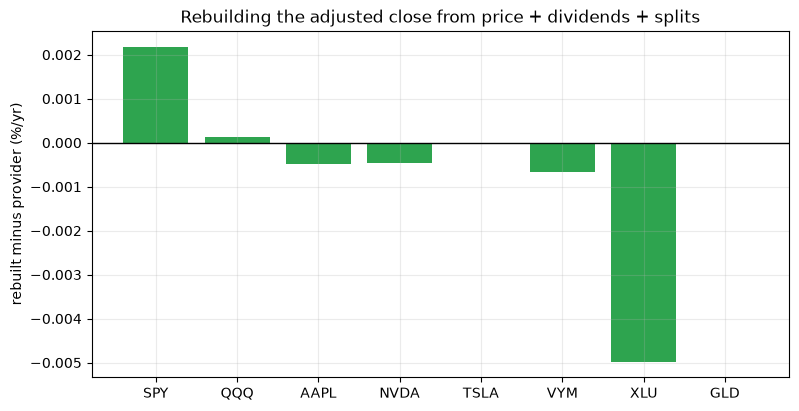

,annualised gap,dividends,splits,terminal ratio
ticker,,,,
SPY,0.0000,135,0,1.0007
QQQ,0.0000,89,1,1.0000
AAPL,-0.0000,68,4,0.9998
NVDA,-0.0000,55,6,0.9999
TSLA,-0.0000,0,2,1.0000
VYM,-0.0000,79,0,0.9999
XLU,-0.0001,111,1,0.9986
GLD,-0.0000,0,0,1.0000


In [5]:
rows = []
for tk, fr in tapes.items():
    rec = st.reconstruct_total_return(fr["daily_raw"])
    if rec.get("available"):
        rows.append({"ticker": tk, "annualised gap": rec["annualised_gap"],
                     "dividends": rec["n_dividends"], "splits": rec["n_splits"],
                     "terminal ratio": rec["terminal_ratio"]})
d = pd.DataFrame(rows).set_index("ticker")
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#c0392b" if abs(v) > 0.005 else "#2ea44f" for v in d["annualised gap"]]
ax.bar(d.index, d["annualised gap"] * 100, color=colors)
ax.axhline(0, color="k", lw=1)
ax.set_ylabel("rebuilt minus provider (%/yr)")
ax.set_title("Rebuilding the adjusted close from price + dividends + splits")
plt.show()
d.round(5)

> \U0001F52C **For the quants.** A negative bar means the reconstruction fell short — the feed
> credits more total return than its own dividend column accounts for. A positive one means the
> opposite. Either way the size, not the sign, is what a backtest inherits.

### 4.3 Missing sessions

In [6]:
rows = []
for tk, fr in tapes.items():
    cg = st.calendar_gaps(fr["daily_tr"], calendar)
    rows.append({"ticker": tk, "missing": cg["n_missing"], "coverage": cg["coverage"],
                 "examples": ", ".join(cg["missing_dates"][:3])})
pd.DataFrame(rows).set_index("ticker")

,missing,coverage,examples
ticker,,,
SPY,0,1.0000,
QQQ,0,1.0000,
AAPL,0,1.0000,
NVDA,0,1.0000,
TSLA,0,1.0000,
VYM,0,1.0000,
XLU,0,1.0000,
GLD,0,1.0000,


### 4.4 Splits, the classic data disaster

In [7]:
for tk, fr in tapes.items():
    sc = st.split_check(fr["daily_raw"], fr["daily_tr"])
    if len(sc):
        print(f"{tk}: {len(sc)} split event(s)")
        print(sc[["date", "ratio", "raw_move", "adjusted_move", "looks_unadjusted"]]
              .head(4).round(3).to_string(index=False))
        print()

QQQ: 1 split event(s)
      date  ratio  raw_move  adjusted_move  looks_unadjusted
2000-03-20 2.0000    0.9720         0.9720             False

AAPL: 4 split event(s)
      date  ratio  raw_move  adjusted_move  looks_unadjusted
2000-06-21 2.0000    1.0990         1.0990             False
2005-02-28 2.0000    1.0080         1.0080             False
2014-06-09 7.0000    1.0160         1.0160             False
2020-08-31 4.0000    1.0340         1.0340             False

NVDA: 6 split event(s)
      date  ratio  raw_move  adjusted_move  looks_unadjusted
2000-06-27 2.0000    0.8590         0.8590             False
2001-09-10 2.0000    0.9710         0.9710             False
2006-04-07 2.0000    0.9970         0.9970             False
2007-09-11 1.5000    1.0210         1.0210             False

TSLA: 2 split event(s)
      date  ratio  raw_move  adjusted_move  looks_unadjusted
2020-08-31 5.0000    1.1260         1.1260             False
2022-08-25 3.0000    0.9970         0.9970          

The expected answer is the counter-intuitive one: with `auto_adjust=False` the provider's OHLC
is **already split-adjusted**, so a 4:1 split should look like an ordinary day in *both*
columns. A `raw_move` near 1/ratio (`looks_unadjusted = True`) would be the fault — a day your
backtest reads as a 75% crash.

## 5 · The verdict

**Signal: Real.** The audit ran **62** checks across 8 tickers and returned **1 errors** and **3 warnings**. The weekly and monthly bars compound from the daily ones to within **4504 bps** at worst; rebuilding the total-return series from price plus dividends and splits reproduces the provider's own adjusted close to **+0.005%/yr** at worst (XLU); and the reference calendar shows **0** missing sessions in total.

**Usefulness: Useful.** The same buy-and-hold statistic computed from the daily tape and from the provider's own weekly bars differs by up to **0.052** of Sharpe and **+0.01%/yr** of CAGR (SPY) — most of which is the arithmetic of measuring volatility at a different frequency rather than a data fault. The fault that *would* change a published number is the reconstruction gap, and the audit prices it at +0.005%/yr.

## 6 · Does the audit even work?

A test that has never failed is not evidence. So the same six checks are run on a synthetic
tape with three faults planted in it at known positions.

In [8]:
frames, truth = data.synthetic_tape(n_years=12, seed=971)
cal = st.build_calendar({"x": frames["daily_tr"]})
clean = st.audit(frames, cal, "CLEAN")
broken_frames, planted = data.corrupt_tape(frames)
broken = st.audit(broken_frames, cal, "BROKEN")
print("planted faults:", planted)
print()
print("clean tape :", dict(st.severity_counts(clean)))
print("broken tape:", dict(st.severity_counts(broken)))
print()
print(broken[broken["severity"] != "info"][["check", "severity", "detail"]].to_string(index=False))

planted faults: {'dropped_session': '2011-12-05', 'unapplied_split_from': '2016-12-16', 'dropped_dividend': '2010-09-24'}

clean tape : {'error': np.int64(0), 'warning': np.int64(0), 'info': np.int64(8)}
broken tape: {'error': np.int64(1), 'warning': np.int64(1), 'info': np.int64(6)}

          check severity                                                                                      detail
resample:weekly    error                              1 of 602 periods differ by more than 10 bps; worst 10003.9 bps
  calendar_gaps  warning 1 sessions missing of 3024 in the reference calendar (coverage 99.9669%); 0 dates not in it


## 7 · Going further \U0001F6AA

- **A second provider** turns self-consistency into cross-validation — the only way to
  establish which feed is right rather than merely coherent.
- **An exchange calendar library** would catch sessions missing from *every* tape, which the
  inferred calendar here structurally cannot.
- **Intraday data** has its own failure modes (out-of-sequence prints, condition codes) that no
  daily audit can see.